### Analytical Evaluation of the Effective Dynamics (FAPT)

While the numerical propagation of the effective state is efficient for single pulse sequences, large parameter sweeps and pulse optimizations require a less computationally demanding approach. To achieve this, the perturbative construction can be evaluated analytically.

Instead of performing the time-evolution numerically over many small steps $\delta t$, this approach uses closed-form symbolic expressions for both the transformation matrix $W(\boldsymbol\lambda)$ and the effective Hamiltonian $H_{\mathrm{eff,ad}}$. The time evolution operator $U(t, t_i)$ over the entire pulse duration is then approximated using the **Magnus expansion** (up to second order), effectively evaluating the evolution in a single analytical step. 

The following code tests this analytical framework by substituting symbolic pulse shapes (like a Gaussian amplitude) into the analytically derived Magnus operator.

In [1]:
from dataclasses import dataclass
from pathlib import Path
import sympy as sp
from utils import * 
from FAPT import * 
from pulse_optimization import * 
s = Simulation()
import matplotlib.pyplot as plt
rH = 2
rW = 1

def setup_paper_style():
    """Sets Matplotlib defaults for scientific publication layouts."""
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Computer Modern", "Times New Roman", "DejaVu Serif"],
        "mathtext.fontset": "cm",
        "text.usetex": False,
        "axes.labelsize": 11.5,
        "font.size": 11,
        "legend.fontsize": 9.0,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "figure.titlesize": 12,
        "axes.titlesize": 11.5,
        "lines.linewidth": 1.4,
        "lines.markersize": 5.0,
    })

In [ ]:
from pathlib import Path
import numpy as np
import sympy as sp
import sympy as sy

DRIVE_DIRECTORY = Path("operational_res/analytical_drive_data")

def load_analytical_drive(pulse_type, drive_directory=DRIVE_DIRECTORY):
    file_path = Path(drive_directory) / f"analytical_drive_{pulse_type}_data.npz"

    if not file_path.exists():
        raise FileNotFoundError(f"Die Datei '{file_path}' wurde nicht gefunden.")

    with np.load(file_path, allow_pickle=False) as saved_data:
        stored_pulse_type = str(saved_data["pulse_type"].item())
        Ar_expression = sp.sympify(saved_data["Ar_srepr"].item())
        Ai_expression = sp.sympify(saved_data["Ai_srepr"].item())
        wd_expression = sp.sympify(saved_data["wd_srepr"].item())

        wd0_serialized = saved_data["wd0_srepr"].item() if "wd0_srepr" in saved_data else ""
        wd0_expression = sp.sympify(wd0_serialized) if wd0_serialized else None

    if stored_pulse_type != pulse_type:
        raise ValueError(f"Angefordert wurde '{pulse_type}', die Datei enthält jedoch '{stored_pulse_type}'.")

    pulse_data = {
        "Ar": Ar_expression,
        "Ai": Ai_expression,
        "wd": wd_expression,
        "wd0": wd0_expression,
    }
    print(f"Symbolische Pulsform geladen: '{file_path}'")
    return pulse_data

# Laden der aa_gauss und aa_tanh Pulsformen
gauss_drive = load_analytical_drive(pulse_type="aa_gauss")
Ar_gauss_expr = gauss_drive["Ar"]
Ai_gauss_expr = gauss_drive["Ai"]
wd_gauss_expr = gauss_drive["wd"]

tanh_drive = load_analytical_drive(pulse_type="aa_tanh")
Ar_tanh_expr = tanh_drive["Ar"]
Ai_tanh_expr = tanh_drive["Ai"]
wd_tanh_expr = tanh_drive["wd"]


def get_symbol_by_name(expressions, symbol_name):
    free_symbols = set().union(*(expression.free_symbols for expression in expressions if expression is not None))
    matching_symbols = [symbol for symbol in free_symbols if symbol.name == symbol_name]

    if not matching_symbols:
        raise KeyError(f"Das Symbol '{symbol_name}' kommt in den geladenen Ausdrücken nicht vor.")
    return matching_symbols[0]

loaded_expressions = (Ar_gauss_expr, Ai_gauss_expr, wd_gauss_expr)
t_sym = get_symbol_by_name(expressions=loaded_expressions, symbol_name="t")
sigma_sym = get_symbol_by_name(expressions=loaded_expressions, symbol_name=r"\sigma")
tg_sym = get_symbol_by_name(expressions=loaded_expressions, symbol_name="t_g")


def replace_loaded_symbols(expression, t_sym, sigma_sym, tg_sym):
    symbol_map = {}
    for symbol in expression.free_symbols:
        if symbol.name == "t":
            symbol_map[symbol] = t_sym
        elif symbol.name in ("sigma", "sigma_r", r"\sigma"):
            symbol_map[symbol] = sigma_sym
        elif symbol.name in ("tg", "t_g", r"t_{g}"):
            symbol_map[symbol] = tg_sym

    return expression.xreplace(symbol_map)


def make_analytical_pulse_builder(Ar_expr, Ai_expr, wd_expr):
    def pulse_shape_builder(t_sym, p_syms):
        tg_sym, sigma_sym, wd_offset_sym, amp_scale_sym = p_syms

        Ar = replace_loaded_symbols(expression=Ar_expr, t_sym=t_sym, sigma_sym=sigma_sym, tg_sym=tg_sym)
        Ai = replace_loaded_symbols(expression=Ai_expr, t_sym=t_sym, sigma_sym=sigma_sym, tg_sym=tg_sym)
        wd_base = replace_loaded_symbols(expression=wd_expr, t_sym=t_sym, sigma_sym=sigma_sym, tg_sym=tg_sym)

        A = amp_scale_sym * (Ar + sy.I * Ai)
        wd = wd_base + wd_offset_sym

        return A, wd

    return pulse_shape_builder

FileNotFoundError: Die Datei 'operational_res/analytical_drive_aa_gauss_data.npz' wurde nicht gefunden.

In [ ]:
def replace_loaded_symbols(expression, t_sym, sigma_sym, tg_sym):
    symbol_map = {}

    for symbol in expression.free_symbols:
        if symbol.name == "t":
            symbol_map[symbol] = t_sym
        elif symbol.name in ("sigma", "sigma_r", r"\sigma"):
            symbol_map[symbol] = sigma_sym
        elif symbol.name in ("tg", "t_g", r"t_{g}"):
            symbol_map[symbol] = tg_sym

    return expression.xreplace(symbol_map)


def make_analytical_pulse_builder(Ar_expr, Ai_expr, dwd_expr):
    def pulse_shape_builder(t_sym, p_syms):
        tg_sym, sigma_sym, wd_offset_sym, amp_scale_sym = p_syms

        Ar = replace_loaded_symbols(expression=Ar_expr, t_sym=t_sym, sigma_sym=sigma_sym, tg_sym=tg_sym)
        Ai = replace_loaded_symbols(expression=Ai_expr, t_sym=t_sym, sigma_sym=sigma_sym, tg_sym=tg_sym)
        dwd = replace_loaded_symbols(expression=dwd_expr, t_sym=t_sym, sigma_sym=sigma_sym, tg_sym=tg_sym)

        A = amp_scale_sym * (Ar + sy.I * Ai)
        wd = wd0_val + dwd + wd_offset_sym

        return A, wd

    return pulse_shape_builder

In [ ]:
# ==============================================================================
# EINMALIGE SYMBOLISCHE FLOQUET-VORBEREITUNG
# ==============================================================================

gauss_drive = load_analytical_drive(pulse_type="gauss")

gauss_pulse_builder = make_analytical_pulse_builder(Ar_expr=gauss_drive["Ar"], Ai_expr=gauss_drive["Ai"], dwd_expr=gauss_drive["dwd"])

base_parameter_names = [
    "t_g",
    "sigma",
    "wd_offset",
    "amp_scale",
]

H_gauss_base, M_gauss_base, M_inv_0_gauss_base = prepare_floquet_functions(pulse_shape_builder=gauss_pulse_builder, p_names=base_parameter_names, s=s, rH=rH, rW=rW, include_geometric=False, include_micromotion=False, include_g_correction=False, verbose=False)

def bind_floquet_functions(tg_target, sigma, H_base=H_gauss_base, M_base=M_gauss_base, M_inv_0_base=M_inv_0_gauss_base):
    def absolute_parameters(offsets):
        # Falls offsets als einzelnes Container-Objekt (Tupel/Liste/Array) übergeben wurde, entpacken
        if len(offsets) == 1 and isinstance(offsets[0], (tuple, list, np.ndarray)):
            offsets = offsets[0]
            
        values = dict(zip(param_names, offsets))
        return values["wd_offset"], values["amp_scale"]

    def H_func(t, *offsets):
        wd_offset, amp_scale = absolute_parameters(offsets)
        return H_base(t, tg_target, sigma, wd_offset, amp_scale)

    def M_func(t, *offsets):
        wd_offset, amp_scale = absolute_parameters(offsets)
        return M_base(t, tg_target, sigma, wd_offset, amp_scale)

    def M_inv_0_func(*offsets):
        wd_offset, amp_scale = absolute_parameters(offsets)
        return M_inv_0_base(tg_target, sigma, wd_offset, amp_scale)

    H_func.is_time_dependent = getattr(H_base, "is_time_dependent", True)
    return H_func, M_func, M_inv_0_func

Symbolische Pulsform geladen: 'operational_res/analytical_drive_data/analytical_drive_gauss.npz'


In [ ]:
s = Simulation()
tg_list = np.linspace(50.0, 700.0, 30)
sigma_r = 0.3
param_ranges = {"wd_offset": (-0.005, 0.005), "amp_scale": (0.8, 1.2)}
param_names = list(param_ranges.keys())

linfid_pop_direct, linfid_pop_floq, linfid_unopt_direct, linfid_unopt_floq = [], [], [], []

def sim_pulse(tg, amp, off):
    Ar = sy.lambdify(t_sym, replace_loaded_symbols(Ar_gauss_expr, t_sym, sigma_r, tg) * amp, "numpy")
    Ai = sy.lambdify(t_sym, replace_loaded_symbols(Ai_gauss_expr, t_sym, sigma_r, tg), "numpy")
    wd = sy.lambdify(t_sym, wd0_val + replace_loaded_symbols(dwd_gauss_expr, t_sym, sigma_r, tg) + off, "numpy")
    q = lambda t, a=None: Ar(t)*np.cos(wd(t)*t) + Ai(t)*np.sin(wd(t)*t)
    U = np.column_stack([[st.overlap(sesolve([s.H0, [s.V1, q]], s.E_states[s.comp_indices[j]], np.linspace(0, tg, max(101, int(tg*8)))).states[-1]) for st in s.E_states[s.comp_indices]] for j in range(4)])
    return infid_population(U)

for tg in tqdm(tg_list):
    H_f, M_f, M_i0_f = bind_floquet_functions(tg, sigma_r)
    p_opt, f_inf = optimize_pulse_parameters(H_f, M_f, M_i0_f, param_ranges, s, tg)
    
    linfid_pop_direct.append(sim_pulse(tg, p_opt["amp_scale"], p_opt["wd_offset"]))
    linfid_pop_floq.append(f_inf)
    
    linfid_unopt_direct.append(sim_pulse(tg, 1.0, 0.0))
    
    tlist = np.linspace(0.0, tg, 200)
    dt = tlist[1] - tlist[0]
    U_unopt = compute_propagator_floquet((0.0, 1.0), H_f, M_f, M_i0_f, tlist[:-1] + dt/2.0, dt, tg, s)
    linfid_unopt_floq.append(infid_population(U_unopt))

Path("operational_res/drag_popfids").mkdir(parents=True, exist_ok=True)
np.savez("operational_res/drag_popfids/drag_popfids_data.npz", tg_list=tg_list, direct=linfid_pop_direct, floq=linfid_pop_floq, unopt_direct=linfid_unopt_direct, unopt_floq=linfid_unopt_floq)

  3%|▎         | 1/30 [00:16<08:11, 16.96s/it]


KeyboardInterrupt: 

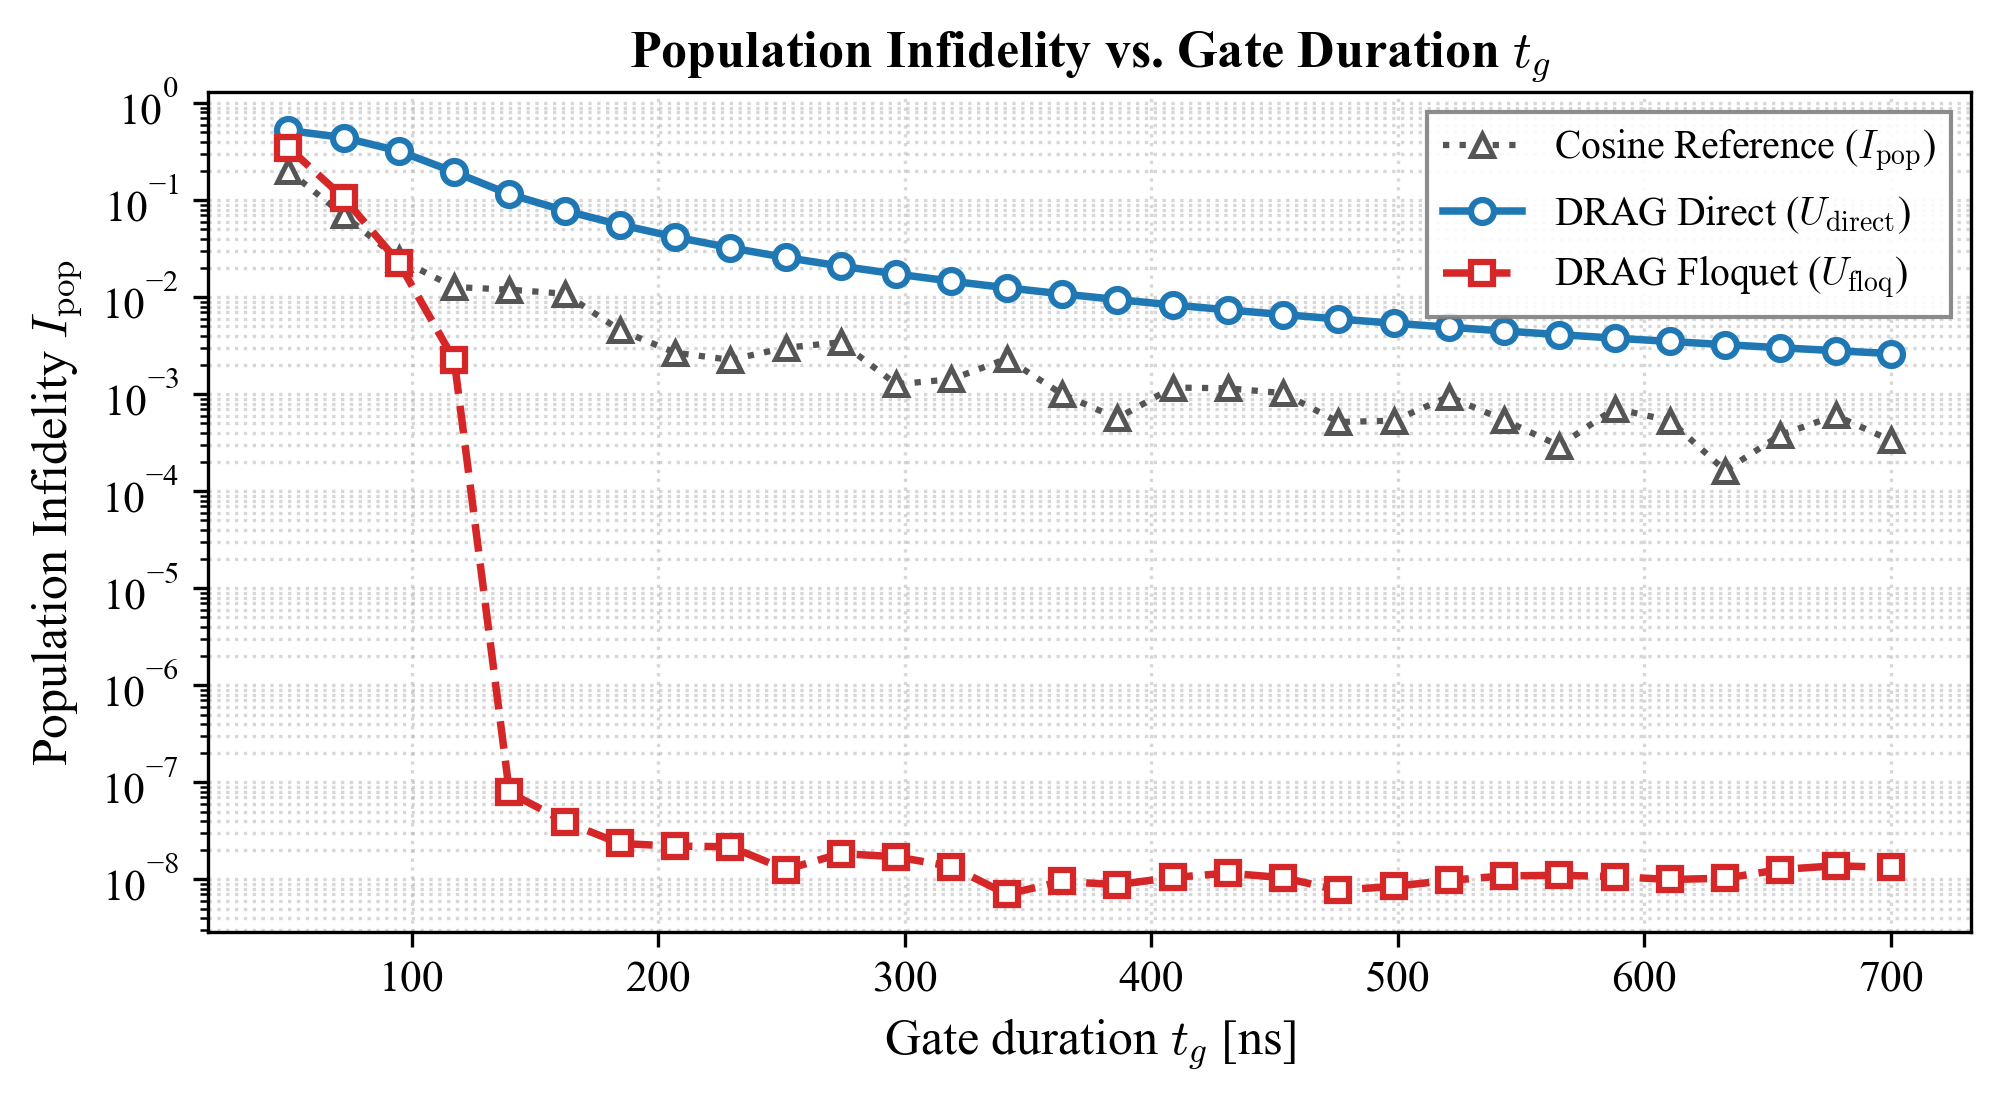

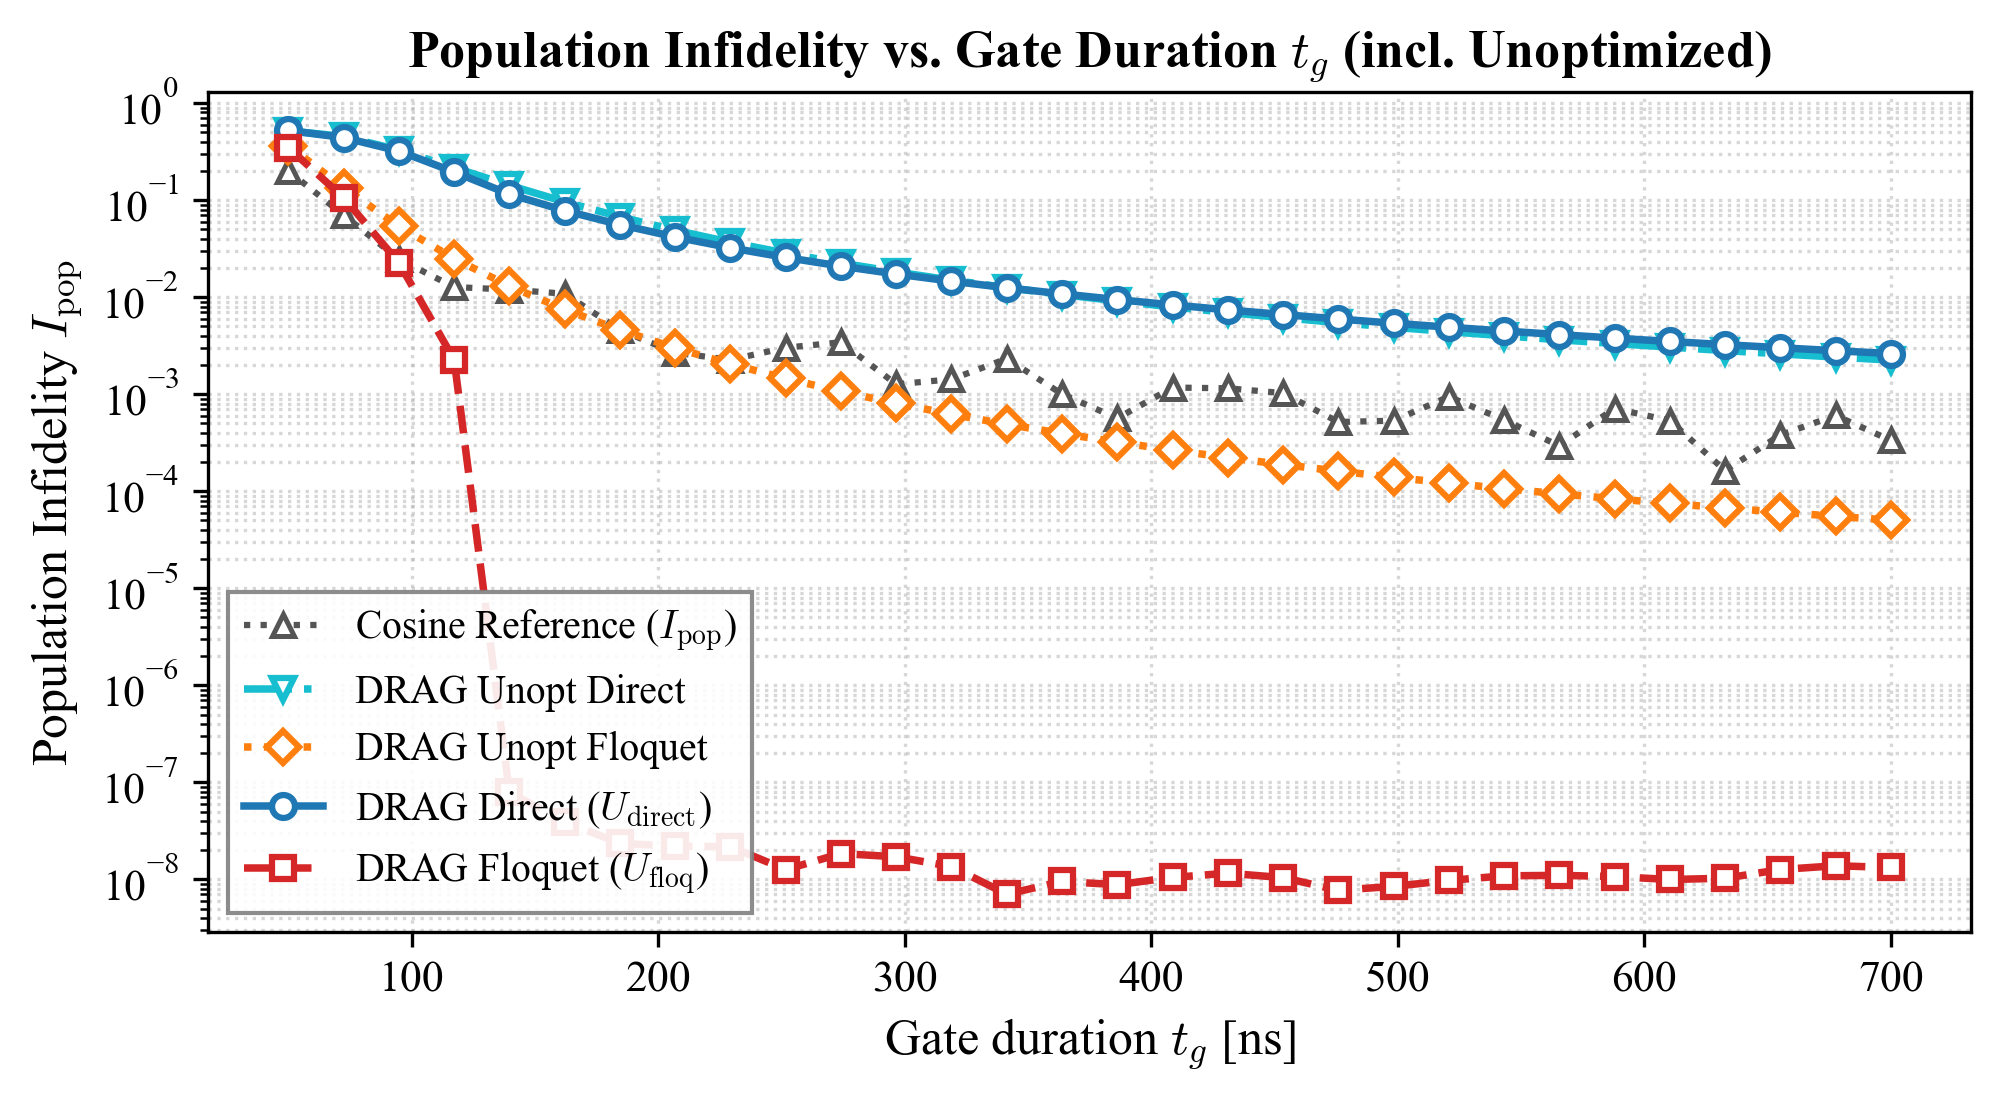

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# Daten laden
ref_data = np.load("operational_res/cos_popfids_data.npz")
ref_tg_list, ref_infid_pop = ref_data["tg_list"], ref_data["infid_pop_list"]

drag_data = np.load("operational_res/drag_popfids/drag_popfids_data.npz")
tg_list = drag_data["tg_list"]
linfid_pop_direct = drag_data["direct"]
linfid_pop_floq = drag_data["floq"]
linfid_unopt_direct = drag_data["unopt_direct"]
linfid_unopt_floq = drag_data["unopt_floq"]


def plot_infidelity_vs_tg_fullwidth(
    tg_list, 
    linfid_pop_direct, 
    linfid_pop_floq, 
    linfid_unopt_direct=None,
    linfid_unopt_floq=None,
    ref_tg_list=None, 
    ref_infid_pop=None, 
    title_suffix="",
    save_path=None, 
    show=True
):
    setup_paper_style()
    
    # Farben
    c_direct, c_floq, c_ref = "#1f77b4", "#d62728", "#555555"
    c_unopt_dir, c_unopt_flq = "#17becf", "#ff7f0e"  # Cyan & Orange für unoptimiert

    fullwidth_style = {
        "axes.labelsize": 12.0, "axes.titlesize": 12.5,
        "xtick.labelsize": 10.5, "ytick.labelsize": 10.5,
        "legend.fontsize": 9.5, "lines.linewidth": 1.8, "lines.markersize": 5.5,
    }
    
    with plt.rc_context(fullwidth_style):
        fig, ax = plt.subplots(figsize=(6.8, 3.8), dpi=300)
        
        # 1. Cosine Reference
        if ref_tg_list is not None and ref_infid_pop is not None:
            ax.semilogy(
                ref_tg_list, ref_infid_pop, ":", color=c_ref, marker="^", 
                mfc="white", mec=c_ref, mew=1.2, lw=1.5, label=r"Cosine Reference ($I_{\mathrm{pop}}$)"
            )
        
        # 2. Unoptimierte Kurven (optional)
        if linfid_unopt_direct is not None:
            ax.semilogy(
                tg_list, linfid_unopt_direct, "-.", color=c_unopt_dir, marker="v", 
                mfc="white", mec=c_unopt_dir, mew=1.5, label=r"DRAG Unopt Direct"
            )
        if linfid_unopt_floq is not None:
            ax.semilogy(
                tg_list, linfid_unopt_floq, ":", color=c_unopt_flq, marker="D", 
                mfc="white", mec=c_unopt_flq, mew=1.5, label=r"DRAG Unopt Floquet"
            )

        # 3. Optimierte Kurven
        ax.semilogy(
            tg_list, linfid_pop_direct, "-", color=c_direct, marker="o", 
            mfc="white", mec=c_direct, mew=1.5, label=r"DRAG Direct ($U_{\mathrm{direct}}$)"
        )
        ax.semilogy(
            tg_list, linfid_pop_floq, "--", color=c_floq, marker="s", 
            mfc="white", mec=c_floq, mew=1.5, label=r"DRAG Floquet ($U_{\mathrm{floq}}$)"
        )
        
        ax.set_xlabel(r"Gate duration $t_g$ [ns]")
        ax.set_ylabel(r"Population Infidelity $I_{\mathrm{pop}}$")
        ax.set_title(rf"Population Infidelity vs. Gate Duration $t_g${title_suffix}", fontweight="bold")
        ax.grid(True, which="both", linestyle=":", alpha=0.5, linewidth=0.8)
        ax.legend(loc="best", frameon=True, fancybox=False, edgecolor="gray", framealpha=0.9)
        
        fig.tight_layout()
        if save_path:
            out = Path(save_path)
            out.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(out, bbox_inches="tight")
        if show:
            plt.show()
            
        return fig, ax


# ==============================================================================
# 2 GETRENNTE PLOTS ERZEUGEN
# ==============================================================================

# Plot 1: Standard (nur optimierte DRAG-Daten)
fig1, ax1 = plot_infidelity_vs_tg_fullwidth(
    tg_list, linfid_pop_direct, linfid_pop_floq,
    ref_tg_list=ref_tg_list, ref_infid_pop=ref_infid_pop,
    save_path="Figure/gauss_floq_vs_direct_infidelity_vs_tg.pdf"
)

# Plot 2: Mit zusätzlichen unoptimierten Referenzkurven
fig2, ax2 = plot_infidelity_vs_tg_fullwidth(
    tg_list, linfid_pop_direct, linfid_pop_floq,
    linfid_unopt_direct=linfid_unopt_direct,
    linfid_unopt_floq=linfid_unopt_floq,
    ref_tg_list=ref_tg_list, ref_infid_pop=ref_infid_pop,
    title_suffix=" (incl. Unoptimized)",
    save_path="Figure/gauss_floq_vs_direct_infidelity_vs_tg_with_unopt.pdf"
)

In [ ]:
from pathlib import Path
import json

save_path = Path("operational_res/analytical_pulse_results.json")
save_path.parent.mkdir(parents=True, exist_ok=True)

with save_path.open("w", encoding="utf-8") as file:
    json.dump(results, file, indent=2, default=lambda value: value.item())

print(f"Ergebnisse gespeichert: {save_path}")

Ergebnisse gespeichert: operational_res/analytical_pulse_results.json
